  0%|          | 0/100 [00:00<?, ?it/s]

             open  close   high    low      volume         money
2018-01-02  10.27  10.35  10.35  10.14  10214794.0  1.044845e+08
2018-01-03  10.35  10.40  10.41  10.27   9759985.0  1.011206e+08
2018-01-04  10.36  10.65  10.76  10.36  13185410.0  1.400909e+08
2018-01-05  10.66  10.68  10.81  10.56   8243379.0  8.831909e+07
2018-01-08  10.67  10.63  10.67  10.53   5762615.0  6.098363e+07
2018-01-09  10.59  10.33  10.60  10.29   8624571.0  8.982511e+07
2018-01-10  10.35  10.43  10.53  10.29   8496816.0  8.845270e+07
            open  close  high   low      volume        money
2022-10-24  9.17   9.01  9.52  8.96  34036119.0  313206671.0
2022-10-25  9.07   9.42  9.45  8.98  42931705.0  398739703.0
2022-10-26  9.39   9.35  9.40  9.19  40775667.0  378099752.0
2022-10-27  8.87   8.42  9.06  8.42  46116339.0  393132016.0
2022-10-28  8.19   7.69  8.33  7.60  51727918.0  404619438.0
2022-10-31  7.68   7.80  7.82  7.58  28686548.0  222866755.0
2022-11-01  7.76   7.84  7.86  7.66  22740172.0  1767

  1%|          | 1/100 [00:02<03:24,  2.07s/it]

Min loss 0.3070737467787694 in epoch 0


  2%|▏         | 2/100 [00:04<03:25,  2.10s/it]

...

 66%|██████▌   | 66/100 [02:15<01:09,  2.05s/it]

Min loss 0.19005124010573127 in epoch 65


 68%|██████▊   | 68/100 [02:19<01:07,  2.10s/it]

Min loss 0.18778774667225662 in epoch 67


100%|██████████| 100/100 [03:25<00:00,  1.99s/it]


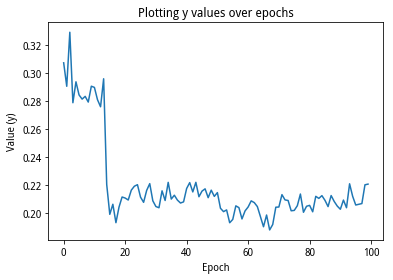

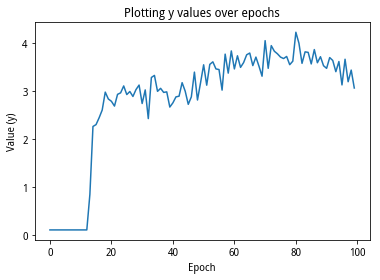

In [6]:
import pandas as pd
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

class stock:
    def __init__(self, df,  window_size=6):
        self.n_actions = 3  # 动作数量
        self.n_features = window_size  # 特征数量
        self.trend = df['close'].values  # 收盘数据
        self.trend_open = df['open'].values
        self.window_size = window_size  # 滑动窗口大小
        self.half_window = window_size // 2
        self.hold_num = 0

    def step(self, action):

        if action == 1:
            self.hold_num = 1
        if action == 2:
            self.hold_num = 0
        if action == 0:
            self.hold_num = self.hold_num

        # self.reward = (self.maket_value - self.last_value) / self.last_value
        reward = (self.trend[self.t + 1] - self.trend[self.t]) / self.trend[self.t]
        #         reward = (self.trend_open[self.t + 2] - self.trend_open[self.t + 1]) / self.trend_open[self.t + 1]
        if np.abs(reward) <= 0.015:
            self.reward = reward * 0.2
        elif np.abs(reward) <= 0.03:
            self.reward = reward * 0.7
        elif np.abs(reward) >= 0.05:
            if reward < 0:
                self.reward = (reward + 0.05) * 0.1 - 0.05
            else:
                self.reward = (reward - 0.05) * 0.1 + 0.05

        # reward = (self.trend[self.t + 1] - self.trend[self.t]) / self.trend[self.t]
        if self.hold_num > 0 or action == 2:
            self.reward = reward
            if action == 2:
                self.reward = -self.reward
        else:
            self.reward = -self.reward * 0.1
            # self.reward = 0

        done = False
        self.t = self.t + 1
        if self.t == len(self.trend) - 2:
            done = True
        s_ = self.get_state(self.t)
        reward = self.reward
#         print(reward)
        return s_, reward, done

    def get_state(self, t):  # 某t时刻的状态
        window_size = self.window_size + 1
        d = t - window_size + 1
        block = []
        if d < 0:
            for i in range(-d):
                block.append(self.trend[0])
            for i in range(t + 1):
                block.append(self.trend[i])
        else:
            block = self.trend[d: t + 1]

        res = []
        for i in range(window_size - 1):
            res.append((block[i + 1] - block[i]) / (block[i] + 0.0001))  # 每步收益
        return np.array(res)  # 作为状态编码

    def reset(self):
        self.total_profit = 0  # 总盈利
        self.t = self.window_size // 2  # 时间
        self.reward = 0  # 收益
        return self.get_state(self.t)


class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN, self).__init__()
        units = 32
        self.fc1 = nn.Linear(input_shape, units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(units, n_actions)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x




os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
device = 'cpu'
np.random.seed(1)
torch.manual_seed(41)

date='2022-11-01'
by_date = '2018-01-01'
df= get_price('000065.XSHE', 
              start_date=by_date,
              end_date=date,
             frequency='1d', )
print(df.head(7))
print(df.tail(7))
env = stock(df)



max_round = 100
step = 0
LOSS = []
REWORD = []
net = DQN(6, 3)
net.train()
tgt_net = DQN(6, 3)
tgt_net.train()
learn_step_counter = 0
replace_target_iter = 200
batch_size = 512
lr = 0.001
gamma = 0.9

epsilon = 200
epsilon_increment = None
epsilon_max = 0.9
memory_size = 4000
n_features = 6
optimizer = optim.Adam(net.parameters(), lr=lr)
min_validation_loss = 9999
for episode in tqdm(range(max_round)):

    # initial observation
    observation = env.reset()
    l = 0
    r = 0
    memory_counter = 0
    memory = np.zeros((memory_size, n_features * 2 + 2))
    while True:
        Observation = [observation[np.newaxis, :]]
        Observation = torch.tensor(Observation, dtype=torch.float32).to(device)
        # forward feed the observation and get q value for every actions
        actions_value = net(Observation).detach().cpu().squeeze(0)
        action = np.argmax(actions_value)
#         print(action)
        # RL take action and get next observation and reward
        observation_, reward, done = env.step(action)
        r = r + reward
        transition = np.hstack((observation, [action, reward], observation_))
        # replace the old memory with new memory
        index = memory_counter % memory_size
        memory[index, :] = transition
        memory_counter += 1
        if learn_step_counter % replace_target_iter == 0:
            tgt_net.load_state_dict(net.state_dict())
        # sample batch memory from all memory
        if memory_counter > memory_size:
            sample_index = np.random.choice(memory_size, size=batch_size)
        else:
            sample_index = np.random.choice(memory_counter, size=batch_size)
        batch_memory = memory[sample_index, :]

        s_ = torch.tensor(batch_memory[:, -n_features:], dtype=torch.float32).to(device)
        s = torch.tensor(batch_memory[:, :n_features], dtype=torch.float32).to(device)
        eval_act_index = batch_memory[:, n_features].astype(int)
        reward = torch.tensor(batch_memory[:, n_features + 1], dtype=torch.float32)
        q_next = tgt_net(s_)
        q_eval = net(s)
        # # change q_target w.r.t q_eval's action
        q_target = q_eval.clone()
        batch_index = np.arange(batch_size, dtype=np.int32)
        max_, _ = torch.max(q_next, dim=1)

        q_target[batch_index, eval_act_index] = reward + gamma * max_

        # loss backpropogation
        optimizer.zero_grad()
        loss = nn.MSELoss()(q_eval, q_target)

        loss.backward()
        optimizer.step()


        # increasing epsilon
        epsilon = epsilon + epsilon_increment if epsilon < epsilon_max else epsilon_max
        learn_step_counter += 1

        # swap observation
        observation = observation_

        # break while loop when end of this episode
        if done:
            break
        step += 1
        l = l + loss.detach().cpu().numpy()
    if min_validation_loss > l:
        min_validation_loss = l
        best_epoch = episode
        print('Min loss ' + str(min_validation_loss) + ' in epoch ' + str(best_epoch))
        torch.save(net.state_dict(), 'tgt_net.pt')

    LOSS.append(l)
    REWORD.append(r)

    
x_values = np.arange(len(LOSS))  # 假设epoch是从0开始的整数序列
plt.plot(x_values, LOSS)
plt.xlabel('Epoch')
plt.ylabel('Value (y)')
plt.title('Plotting y values over epochs')
plt.show()

plt.plot(x_values, REWORD)
plt.xlabel('Epoch')
plt.ylabel('Value (y)')
plt.title('Plotting y values over epochs')
plt.show()
